
DATASET INFORMATION

Dataset Shape:
(278, 9)

Column Names:
1 : Particle Material
2 : Base liquid
3 : Temperature (°C)
4 : Particle size (nm)
5 : Particle volume fraction (%)
6 : km (Thermal Conductivity of liquid)
7 : kp (thermal Conductivity of Particle)
8 : Thermal Conductivity as per Experimental Paper
9 : Thermal Conductivity using KKL Model

SELECTED VARIABLES

Input Columns C, D, E, F:
['Temperature (°C)', 'Particle size (nm)', 'Particle volume fraction (%)', 'km (Thermal Conductivity of liquid)']

Target Column K:
Thermal Conductivity as per Experimental Paper

Missing Values Before Cleaning:
Temperature (°C)                                  0
Particle size (nm)                                0
Particle volume fraction (%)                      0
km (Thermal Conductivity of liquid)               0
Thermal Conductivity as per Experimental Paper    0
dtype: int64

Dataset Shape After Cleaning:
(278, 4)

DATA SPLIT

Training: 194
Validation: 42
Testing: 42

TRAINING ANN
Iteration 

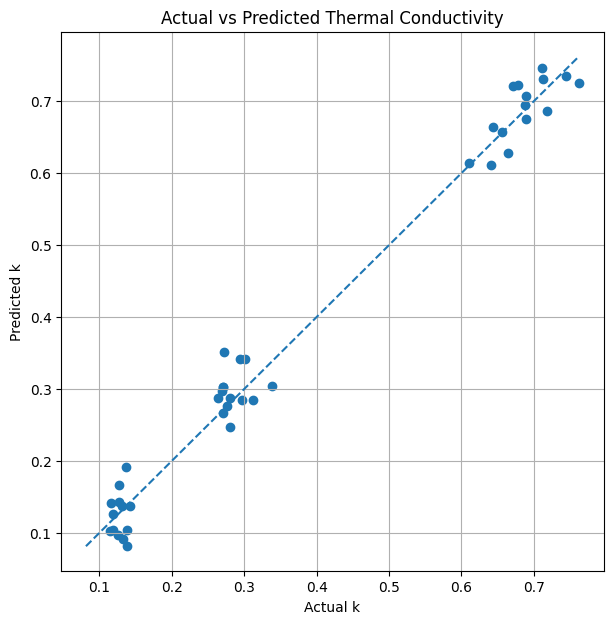

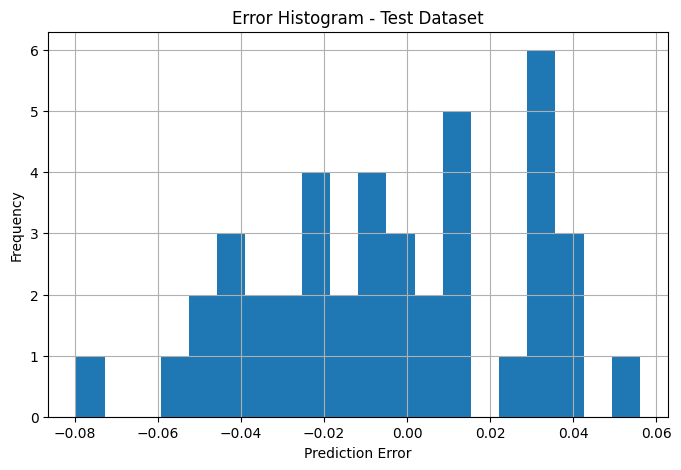

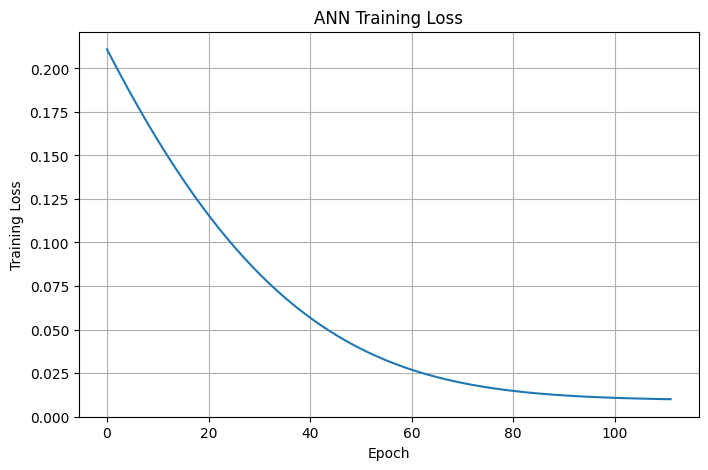

In [2]:
# ============================================================
# ANN 4-12-1
# Input  : Excel Columns C, D, E, F
# Target : Excel Column K
# File   : 1.xlsx
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)


# ============================================================
# 1. Read Excel File
# ============================================================

file_name = "1.xlsx"

data = pd.read_excel(file_name)


print("\n==========================================")
print("DATASET INFORMATION")
print("==========================================")

print("\nDataset Shape:")
print(data.shape)

print("\nColumn Names:")
for i, col in enumerate(data.columns):
    print(i + 1, ":", col)


# ============================================================
# 2. Select Input and Target Columns
# ============================================================
#
# Excel:
#
# Column C = Input 1
# Column D = Input 2
# Column E = Input 3
# Column F = Input 4
#
# Column K = Target
#
# Python indexing starts from 0:
#
# C -> index 2
# D -> index 3
# E -> index 4
# F -> index 5
# K -> index 10
#
# ============================================================


# ============================================================
# Input: Columns C, D, E, F
# Target: Column H (Experimental Thermal Conductivity)
# ============================================================

X = data.iloc[:, [2, 3, 4, 5]].copy()

y = data.iloc[:, 7].copy()


print("\n==========================================")
print("SELECTED VARIABLES")
print("==========================================")

print("\nInput Columns C, D, E, F:")

print(
    X.columns.tolist()
)


print("\nTarget Column K:")

print(
    y.name
)


# ============================================================
# 3. Convert Data to Numeric
# ============================================================

X = X.apply(
    pd.to_numeric,
    errors="coerce"
)

y = pd.to_numeric(
    y,
    errors="coerce"
)


# ============================================================
# 4. Remove Missing Values
# ============================================================

combined_data = pd.concat(

    [X, y],

    axis=1

)


print("\nMissing Values Before Cleaning:")

print(
    combined_data.isnull().sum()
)


combined_data = combined_data.dropna().reset_index(
    drop=True
)


# Re-create X and y

X = combined_data.iloc[:, 0:4].values

y = combined_data.iloc[:, 4].values


print("\nDataset Shape After Cleaning:")

print(
    X.shape
)


# ============================================================
# 5. Split Dataset
# ============================================================
#
# 70% Training
# 15% Validation
# 15% Testing
#
# ============================================================


X_train, X_temp, y_train, y_temp = train_test_split(

    X,

    y,

    test_size=0.30,

    random_state=42

)


X_val, X_test, y_val, y_test = train_test_split(

    X_temp,

    y_temp,

    test_size=0.50,

    random_state=42

)


print("\n==========================================")
print("DATA SPLIT")
print("==========================================")


print(
    "\nTraining:",
    len(X_train)
)


print(
    "Validation:",
    len(X_val)
)


print(
    "Testing:",
    len(X_test)
)


# ============================================================
# 6. Scale Input Data
# ============================================================

scaler_X = StandardScaler()

X_train_scaled = scaler_X.fit_transform(
    X_train
)

X_val_scaled = scaler_X.transform(
    X_val
)

X_test_scaled = scaler_X.transform(
    X_test
)


# ============================================================
# 7. Scale Target Data
# ============================================================

scaler_y = StandardScaler()


y_train_scaled = scaler_y.fit_transform(

    y_train.reshape(-1, 1)

).ravel()


y_val_scaled = scaler_y.transform(

    y_val.reshape(-1, 1)

).ravel()


y_test_scaled = scaler_y.transform(

    y_test.reshape(-1, 1)

).ravel()


# ============================================================
# 8. Create ANN 4-12-1
# ============================================================
#
# 4 Input Neurons
#       |
#       v
# 12 Hidden Neurons
#       |
#       v
# 1 Output Neuron
#
# ============================================================


model = MLPRegressor(

    hidden_layer_sizes=(12,),

    activation="tanh",

    solver="adam",

    max_iter=2000,

    early_stopping=False,

    random_state=42,

    verbose=True

)


# ============================================================
# 9. Train ANN
# ============================================================


print("\n==========================================")
print("TRAINING ANN")
print("==========================================")


model.fit(

    X_train_scaled,

    y_train_scaled

)


print("\nTraining Completed.")


print(
    "Number of Epochs:",
    model.n_iter_
)


# ============================================================
# 10. Prediction
# ============================================================


y_train_pred_scaled = model.predict(

    X_train_scaled

)


y_val_pred_scaled = model.predict(

    X_val_scaled

)


y_test_pred_scaled = model.predict(

    X_test_scaled

)


# ============================================================
# 11. Convert Predictions to Original Scale
# ============================================================


y_train_pred = scaler_y.inverse_transform(

    y_train_pred_scaled.reshape(-1, 1)

).ravel()


y_val_pred = scaler_y.inverse_transform(

    y_val_pred_scaled.reshape(-1, 1)

).ravel()


y_test_pred = scaler_y.inverse_transform(

    y_test_pred_scaled.reshape(-1, 1)

).ravel()


# ============================================================
# 12. Evaluation Function
# ============================================================


def evaluate_model(y_true, y_pred):

    mse = mean_squared_error(

        y_true,

        y_pred

    )


    rmse = np.sqrt(mse)


    mae = mean_absolute_error(

        y_true,

        y_pred

    )


    r2 = r2_score(

        y_true,

        y_pred

    )


    # Avoid division by zero in MAPE

    non_zero = y_true != 0


    mape = np.mean(

        np.abs(

            (
                y_true[non_zero]
                -
                y_pred[non_zero]
            )

            /

            y_true[non_zero]

        )

    ) * 100


    # Correlation coefficient R

    R = np.corrcoef(

        y_true,

        y_pred

    )[0, 1]


    return {

        "MSE": mse,

        "RMSE": rmse,

        "MAE": mae,

        "MAPE (%)": mape,

        "R": R,

        "R2": r2

    }


# ============================================================
# 13. Evaluate Training
# ============================================================


train_results = evaluate_model(

    y_train,

    y_train_pred

)


# ============================================================
# 14. Evaluate Validation
# ============================================================


val_results = evaluate_model(

    y_val,

    y_val_pred

)


# ============================================================
# 15. Evaluate Testing
# ============================================================


test_results = evaluate_model(

    y_test,

    y_test_pred

)


# ============================================================
# 16. Display Results
# ============================================================


results = pd.DataFrame({

    "Training":
        train_results,

    "Validation":
        val_results,

    "Testing":
        test_results

})


print("\n==========================================")
print("FINAL RESULTS")
print("==========================================")


print(

    results.round(6)

)


# ============================================================
# 17. Save Results
# ============================================================


results.to_excel(

    "ANN_Results.xlsx"

)


print(

    "\nResults saved to ANN_Results.xlsx"

)


# ============================================================
# 18. Actual vs Predicted - Test Data
# ============================================================


plt.figure(

    figsize=(7, 7)

)


plt.scatter(

    y_test,

    y_test_pred

)


min_value = min(

    y_test.min(),

    y_test_pred.min()

)


max_value = max(

    y_test.max(),

    y_test_pred.max()

)


plt.plot(

    [

        min_value,

        max_value

    ],

    [

        min_value,

        max_value

    ],

    linestyle="--"

)


plt.xlabel(

    "Actual k"

)


plt.ylabel(

    "Predicted k"

)


plt.title(

    "Actual vs Predicted Thermal Conductivity"

)


plt.grid(

    True

)


plt.show()


# ============================================================
# 19. Error Histogram
# ============================================================


test_errors = (

    y_test

    -

    y_test_pred

)


plt.figure(

    figsize=(8, 5)

)


plt.hist(

    test_errors,

    bins=20

)


plt.xlabel(

    "Prediction Error"

)


plt.ylabel(

    "Frequency"

)


plt.title(

    "Error Histogram - Test Dataset"

)


plt.grid(

    True

)


plt.show()


# ============================================================
# 20. Training Loss Curve
# ============================================================


plt.figure(

    figsize=(8, 5)

)


plt.plot(

    model.loss_curve_

)


plt.xlabel(

    "Epoch"

)


plt.ylabel(

    "Training Loss"

)


plt.title(

    "ANN Training Loss"

)


plt.grid(

    True

)


plt.show()